Fundamentals of Deep Learning Models

# Lab 04-2: Regularization for Deep Neural Networks
## Exercise: Predicting MNIST digits with dropout and L2 regularization

This exercise implements **dropout regularization** (Section 4.6, Eqs. 4.35–4.37) and **L2 regularization** (Section 4.5, Eqs. 4.28–4.29) for a three-layer neural network trained on the mini-MNIST digit dataset. The dropout layer uses **inverted dropout** scaling (Section 4.6) so that no rescaling is needed at inference time. L2 regularization adds the penalty gradient $2\lambda\mathbf{W}$ to the weight gradients during backpropagation (Eq. 4.29). Additionally, a weight initialization utility supporting Xavier (Eq. 4.20–4.21) and He (Eq. 4.22–4.23) initialization is provided.

**Note:** The dense layer, activation backpropagation, and optimizer functions are reused from Labs 03-3 and 04-1. This lab focuses on the dropout and regularization implementations. Mini-batch gradient descent (Eq. 4.7) is used for training.

### Prepare mini-MNIST dataset

The dataset is `sklearn.datasets.load_digits` (1,797 images, 8×8 pixels, $M = 64$ features, $K = 10$ classes). Features are standardized to zero mean and unit variance via `StandardScaler`. Target labels are one-hot encoded.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import __version__ as sklearn_version

print('Numpy version:', np.__version__)
print('Matplotlib version:', plt.matplotlib.__version__)
print('scikit-learn version:', sklearn_version)

Numpy version: 2.0.2
Matplotlib version: 3.10.0
scikit-learn version: 1.6.1


In [2]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

digits = load_digits()

# Flatten 8x8 images into 64-dimensional feature vectors
digits_df = digits.images.reshape((len(digits.target), -1))
digits_tf = digits.target

# Split into training (80%) and test (20%) sets
X_train_org, X_test_org, y_train_num, y_test = train_test_split(
    digits_df, digits_tf, test_size=0.20, random_state=101)

# Standardize features to zero mean and unit variance
sc = StandardScaler()
X_train = sc.fit_transform(X_train_org)
X_test = sc.transform(X_test_org)

n_classes = 10

# Convert integer labels to one-hot encoded vectors (N x 10)
y_train = np.zeros((y_train_num.shape[0], 10))
for i in range(n_classes):
    y_train[:, i] = (y_train_num == i)

#### Define utility functions

In [3]:
from tensorflow.math import sigmoid as tf_sigmoid
from tensorflow.nn import softmax as tf_softmax

def sigmoid(x):
    x = tf_sigmoid(x)
    return x.numpy()

def softmax(x):
    x = tf_softmax(x)
    return x.numpy()

In [4]:
def create_mini_batches(X, y, batch_size=64):
    data = np.hstack((X, y))
    np.random.shuffle(data)
    X_batches, y_batches = np.split(data, (X.shape[1],), axis=1)
    X_mini = np.split(X_batches, np.arange(batch_size, len(X), batch_size), axis=0)
    y_mini = np.split(y_batches, np.arange(batch_size, len(X), batch_size), axis=0)
    mini_batches = zip(X_mini, y_mini)
    return mini_batches

(1797, 64)
(1437, 64)
(1437, 10)
[ 0.  0.  0.  9. 16.  6.  0.  0.  0.  0.  4. 15.  6. 15.  0.  0.  0.  0.
  8. 11.  9. 11.  0.  0.  0.  0.  8. 16. 14.  2.  0.  0.  0.  0. 11. 16.
 13.  0.  0.  0.  0.  6. 14.  2. 12.  9.  0.  0.  0.  5. 16. 11.  5. 13.
  4.  0.  0.  0.  3.  8. 13. 16.  9.  0.]


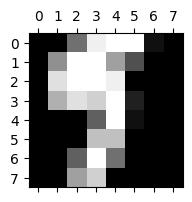

The number is 5


In [5]:
print(digits_df.shape)
print(X_train.shape)
print(y_train.shape)
print(X_train_org[0])

idx = np.random.randint(X_train.shape[0])
dimage = X_train_org[idx].reshape((8, 8))
plt.figure(figsize=(2, 2))
plt.gray()
plt.matshow(dimage, fignum=0)
plt.show()
print('The number is', y_train_num[idx])

### Simple DNN for digit classification

#### Define dense layer class (from Lab 03-3)

In [ ]:
class myDenseLayer:
    def __init__(self, n_out, n_in):
        self.weight = np.empty((n_out, n_in))
        self.bias = np.zeros((n_out))
        self.saved_x = None

    def forward(self, x):   # x: (b, i)

        ### START CODE HERE ###

        # Save input for use in backward pass
        self.saved_x = None
        # Compute linear transformation: z = W * x^T + b  (Eq. 3.28)
        x_lin = None

        ### END CODE HERE ###

        return x_lin

    def backward(self, x):  # x = dJ/dz (b, c)

        ### START CODE HERE ###

        # Compute weight gradient: dJ/dW = (dJ/dz)^T * a^{[l-1]} / N  (Eq. 3.30)
        dw = None
        # Compute bias gradient: dJ/db = mean(dJ/dz)  (Eq. 3.31)
        db = None
        # Propagate gradient to lower layer: W^T * dJ/dz  (Eq. 3.29)
        wdJdz = None

        ### END CODE HERE ###

        return dw, db, wdJdz

#### Define dropout layer class

Dropout (Section 4.6) randomly sets a fraction $p$ of node outputs to zero during training (Eq. 4.35). **Inverted dropout** scales the remaining outputs by $1/(1-p)$ so that no rescaling is needed at inference (Section 4.6). During backpropagation, the same mask is reused (Eq. 4.36).

**Hint:** Use `np.random.binomial` to generate the Bernoulli mask $\mathbf{M}_p$.

In [ ]:
class myDropoutLayer:
    def __init__(self, rate=0.5):
        self.mask = None
        self.rate = rate

    def forward(self, x, training):

        ### START CODE HERE ###

        if training:
            # Generate Bernoulli mask with inverted scaling: M_p / (1-p)  (Eq. 4.35)
            self.mask = None
            # Apply mask: a(z) = M_p * g(z)  (Eq. 4.35)
            x = None

        ### END CODE HERE ###

        return x

    def backward(self, x):

        ### START CODE HERE ###

        # Reuse the same mask during backpropagation  (Eq. 4.36)
        x = None

        ### END CODE HERE ###

        return x

In [8]:
tlyr = myDropoutLayer()
np.random.seed(101)
a = np.random.randn(10)
b = np.random.randn(10)
c = tlyr.forward(a, training=True)
d = tlyr.backward(b)
c_exp = [5.41369968, 1.25626542, 1.81593889, 1.00765151, 0., -0., -1.69615397, 0., -4.03633649, 1.48024411]
d_exp = [1.05762699, -1.17800107, 0.37739062, -1.51774411, -0., 0., 0.38158864, 0., 5.21193456, 1.36701777]
print(str(c) + '\n' + str(d))
print('test passed.') if np.allclose([c, d], [c_exp, d_exp]) else print('test failed.')

[ 5.41369968  1.25626542  1.81593889  1.00765151  0.         -0.
 -1.69615397  0.         -4.03633649  1.48024411]
[ 1.05762699 -1.17800107  0.37739062 -1.51774411 -0.          0.
  0.38158864  0.          5.21193456  1.36701777]
test passed.


**Expected output:**

```
[ 5.41369968  1.25626542  1.81593889  1.00765151  0.         -0.
 -1.69615397  0.         -4.03633649  1.48024411]
[ 1.05762699 -1.17800107  0.37739062 -1.51774411 -0.          0.
  0.38158864  0.          5.21193456  1.36701777]
```

#### Define backpropagation through activation functions (from Lab 03-3)

In [ ]:
def dJdz_sigmoid(wdJdz_upper, a_l):

    ### START CODE HERE ###

    # Element-wise: dJ/dz = (W^T dJ/dz_upper) * a * (1 - a)  (Eq. 3.29)
    dJdz = None

    ### END CODE HERE ###

    return dJdz

def dJdz_softmax(y_hat, y):

    ### START CODE HERE ###

    # Softmax + cross-entropy gradient: dJ/dz = y_hat - y  (Eq. 3.32)
    dJdz = None

    ### END CODE HERE ###

    return dJdz

#### Define training functions with dropout and L2 regularization

The forward pass applies dropout after each hidden layer's activation (Eq. 4.35). The backward pass routes gradients through the dropout mask (Eq. 4.37) and adds the L2 regularization gradient $2\lambda\mathbf{W}$ to each layer's weight gradient (Eq. 4.29). During loss evaluation and prediction, dropout is disabled (`training=False`).

#### Create a NN model and check matrix dimensions

In [10]:
n_inputs  = 64
n_hidden1 = 80
n_hidden2 = 70
n_classes = 10

l1 = myDenseLayer(n_hidden1, n_inputs)
d1 = myDropoutLayer(rate=0.5)
l2 = myDenseLayer(n_hidden2, n_hidden1)
d2 = myDropoutLayer(rate=0.5)
l3 = myDenseLayer(n_classes, n_hidden2)

layers = [l1, d1, l2, d2, l3]

print(X_train.shape, y_train.shape)
print(l1.weight.shape, l1.bias.shape)
print(l2.weight.shape, l2.bias.shape)
print(l3.weight.shape, l3.bias.shape)

(1437, 64) (1437, 10)
(80, 64) (80,)
(70, 80) (70,)
(10, 70) (10,)


In [ ]:
def my_forward(layers, X_in):
    l1, d1, l2, d2, l3 = layers

    ### START CODE HERE ###

    # Layer 1: sigmoid activation + dropout
    a_1 = None
    d_1 = None
    # Layer 2: sigmoid activation + dropout
    a_2 = None
    d_2 = None
    # Layer 3: softmax output (no dropout on output layer)
    a_3 = None

    ### END CODE HERE ###
    
    return a_1, a_2, a_3

def my_backward(layers, a_1, a_2, a_3, y_true, l2_lambda=1e-2):
    l1, d1, l2, d2, l3 = layers

    ### START CODE HERE ###

    # Backpropagation gradients and L2 regularization gradients for all layers 
    # Layer 3 backprop + L2 gradient: dw += 2 * lambda * W  (Eq. 4.29)
    dw_3, db_3, wdJdz_3 = None
    dw_3 = None
    # Layer 2 backprop: route gradient through dropout mask  (Eq. 4.37)
    dw_2, db_2, wdJdz_2 = None
    dw_2 = None
    # Layer 1 backprop: route gradient through dropout mask  (Eq. 4.37)
    dw_1, db_1, _ = None
    dw_1 = None

    ### END CODE HERE ###

    d_1 = [dw_1, db_1]
    d_2 = [dw_2, db_2]
    d_3 = [dw_3, db_3]

    return d_1, d_2, d_3

def my_loss(layers, X_in, y_true):
    l1, d1, l2, d2, l3 = layers

    ### START CODE HERE ###

    # Forward pass with dropout disabled (inference mode)
    a_1 = None
    d_1 = None
    a_2 = None
    d_2 = None
    a_3 = None
    # Cross-entropy loss  (Eq. 3.16)
    loss = None

    ### END CODE HERE ###

    return loss

def my_predict(layers, X_in):
    l1, d1, l2, d2, l3 = layers

    ### START CODE HERE ###

    # Forward pass with dropout disabled (inference mode)
    a_1 = None
    d_1 = None
    a_2 = None
    d_2 = None
    a_3 = None
    pred = None

    ### END CODE HERE ###

    return pred

#### Define optimizer

Mini-batch SGD is provided. Other optimizers from Lab 04-1 (Sections 4.2–4.3) can also be used.

In [ ]:
class myOptParam:
    def __init__(self, n_out, n_in):
        # Previous delta values for momentum optimizer
        self.W_dt = np.zeros((n_out, n_in))
        self.B_dt = np.zeros(n_out)
        # First moment (m_t) for Adam
        self.W_mt = np.zeros((n_out, n_in))
        self.B_mt = np.zeros(n_out)
        # Second moment (v_t) for AdaGrad, RMSProp, Adam
        self.W_vt = np.zeros((n_out, n_in))
        self.B_vt = np.zeros(n_out)

def my_optimizer(lyr, opt, W_grad, B_grad, solver='sgd', learning_rate=0.01, iter=1):
    epsilon = 1e-8
    alpha = eta = learning_rate

    if iter == 0:
        print('iteration should start from 1.')

    if solver == 'sgd':
        # SGD update: delta = alpha * g_t  (Eq. 4.1)
        W_dlt = alpha * W_grad
        B_dlt = alpha * B_grad
    elif solver == 'momentum':
        gamma = 0.9
        ### START CODE HERE ###
        pass
        ### END CODE HERE ###
    elif solver == 'adagrad':
        ### START CODE HERE ###
        pass
        ### END CODE HERE ###
    elif solver == 'rmsprop':
        beta2 = 0.9
        ### START CODE HERE ###
        pass
        ### END CODE HERE ###
    elif solver == 'adam':
        beta1, beta2 = 0.9, 0.99
        ### START CODE HERE ###
        pass
        ### END CODE HERE ###
    else:
        print('optimizer error')

    # Apply parameter update: theta_t = theta_{t-1} - delta_t
    lyr.weight = lyr.weight - W_dlt
    lyr.bias = lyr.bias - B_dlt

    return

#### Create optimizer parameters

In [13]:
o1 = myOptParam(n_hidden1, n_inputs)
o2 = myOptParam(n_hidden2, n_hidden1)
o3 = myOptParam(n_classes, n_hidden2)

#### Weight initialization

Supports standard normal, uniform, Xavier/Glorot (Eqs. 4.20–4.21), and He/Kaiming (Eqs. 4.22–4.23) initialization. Xavier initialization sets the variance to $2/(n_\text{in} + n_\text{out})$, while He initialization uses $2/n_\text{in}$ to account for the ReLU activation's zero-output region.

In [14]:
def my_initializer(lyr, pdf='normal'):
    (fan_out, fan_in) = w_shape = lyr.weight.shape
    if pdf == 'normal':
        lyr.weight = np.random.randn(*w_shape)
    elif pdf == 'uniform':
        lyr.weight = np.random.uniform(-1, 1, size=w_shape)
    elif pdf == 'xavier_normal':           # Xavier/Glorot normal  (Eq. 4.20)
        lyr.weight = np.random.randn(*w_shape) * np.sqrt(2 / (fan_out + fan_in))
    elif pdf == 'xavier_uniform':          # Xavier/Glorot uniform  (Eq. 4.21)
        a = np.sqrt(6 / (fan_out + fan_in))
        lyr.weight = np.random.uniform(-a, a, size=w_shape)
    elif pdf == 'he_normal':               # He/Kaiming normal  (Eq. 4.22)
        lyr.weight = np.random.randn(*w_shape) * np.sqrt(2 / fan_in)
    elif pdf == 'he_uniform':              # He/Kaiming uniform  (Eq. 4.23)
        a = np.sqrt(6 / fan_in)
        lyr.weight = np.random.uniform(-a, a, size=w_shape)
    else:
        print('initializer error')
    return

np.random.seed(1)
weight_init = 'normal'
# Biases are set to zeros during layer creation

my_initializer(l1, pdf=weight_init)
my_initializer(l2, pdf=weight_init)
my_initializer(l3, pdf=weight_init)

### Training the neural network model

Train the 3-layer model with dropout ($p = 0.5$) and L2 regularization ($\lambda = 10^{-3}$). Change the `optimizer`, `lmbda`, and `dpout` variables to investigate their effects on convergence and generalization.

In [ ]:
# optimizer settings: 'sgd', 'momentum', 'adagrad', 'rmsprop', 'adam'
optimizer = 'sgd'
alpha = 1e-2      # learning rate
lmbda = 1e-3      # L2 regularization coefficient (lambda in Eq. 4.28)
dpout = 0.5       # dropout rate (p in Eq. 4.35)
n_epochs = 1000

for epoch in range(n_epochs):

    batches = create_mini_batches(X_train, y_train, batch_size=64)
    for one_batch in batches:
        X_mini, y_mini = one_batch
        batch_len = X_mini.shape[0]

        # Forward pass (dropout active during training)
        a_1, a_2, a_3 = my_forward(layers, X_mini)

        # Backward pass (includes L2 gradient and dropout mask)
        d_1, d_2, d_3 = my_backward(layers, a_1, a_2, a_3, y_mini, l2_lambda=lmbda)

        dw_1, db_1 = d_1
        dw_2, db_2 = d_2
        dw_3, db_3 = d_3

        # Update weights and biases
        my_optimizer(l1, o1, dw_1, db_1, solver=optimizer, learning_rate=alpha)
        my_optimizer(l2, o2, dw_2, db_2, solver=optimizer, learning_rate=alpha)
        my_optimizer(l3, o3, dw_3, db_3, solver=optimizer, learning_rate=alpha)

    if ((epoch + 1) % 100 == 0):
        loss_J = my_loss(layers, X_train, y_train)
        print('Epoch: %4d,  loss: %10.8f' % (epoch + 1, loss_J))

Epoch:  100,  loss: 1.13570867
Epoch:  200,  loss: 0.80415322
Epoch:  300,  loss: 0.76594675
Epoch:  400,  loss: 0.73784955
Epoch:  500,  loss: 0.69597402
Epoch:  600,  loss: 0.64245510
Epoch:  700,  loss: 0.58572833
Epoch:  800,  loss: 0.53449354
Epoch:  900,  loss: 0.48407293
Epoch: 1000,  loss: 0.43818577


In [20]:
res = np.concatenate((l1.weight[0:3, 0:5], l2.weight[0:3, 0:5], l3.weight[0:3, 0:5]), axis=0)
print(res)
exp = [[ 1.02541795, -0.44153251, -0.37960304, -0.69605968,  0.46865909],
       [ 0.3083921,   0.15455787,  0.92512941,  0.92284071,  1.2900445 ],
       [-0.75707481,  0.66963681,  0.15346779, -0.26480214, -0.63854713],
       [-0.30614066, -0.36375182,  1.17823531, -0.31186735,  0.12895917],
       [-0.16709706, -0.92991472, -0.43591388,  0.23365694,  0.00346934],
       [-0.78424182, -0.41458865,  0.50564029,  0.57775447, -0.82233508],
       [-1.17871036,  0.36815284,  0.3742723,  -0.14464065, -0.3818652 ],
       [ 0.32585195, -0.3547728,   0.46432518, -0.12741467,  0.64127899],
       [-0.27811803,  0.12747153,  0.41734615,  0.02835775,  0.80436973]]
if weight_init == 'normal':
    print('test passed.') if np.allclose(res, exp) else print('test failed.')
else:
    print('to verify your code, set initializer to ' + '\033[1m' + 'normal' + '\033[0m')

[[ 1.02541795 -0.44153251 -0.37960304 -0.69605968  0.46865909]
 [ 0.3083921   0.15455787  0.92512941  0.92284071  1.2900445 ]
 [-0.75707481  0.66963681  0.15346779 -0.26480214 -0.63854713]
 [-0.30614066 -0.36375182  1.17823531 -0.31186735  0.12895917]
 [-0.16709706 -0.92991472 -0.43591388  0.23365694  0.00346934]
 [-0.78424182 -0.41458865  0.50564029  0.57775447 -0.82233508]
 [-1.17871036  0.36815284  0.3742723  -0.14464065 -0.3818652 ]
 [ 0.32585195 -0.3547728   0.46432518 -0.12741467  0.64127899]
 [-0.27811803  0.12747153  0.41734615  0.02835775  0.80436973]]
test passed.


### Evaluate model performance

In [17]:
from sklearn.metrics import accuracy_score

y_pred = my_predict(layers, X_test)

accuracy_score(y_pred, y_test)

0.9083333333333333

### Comparison with scikit-learn

Compare with `MLPClassifier` using SGD and logistic activation. Note that scikit-learn's implementation includes its own L2 regularization (`alpha` parameter) but does not support dropout.

In [18]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(80, 70,), activation='logistic', solver='sgd',
                    alpha=0.01, learning_rate_init=0.01, max_iter=1000)

# Training the model
mlp.fit(X_train, y_train_num)

# Evaluate on test set
s_pred = mlp.predict(X_test)
accuracy_score(s_pred, y_test)

0.9722222222222222

### Test model with a random sample

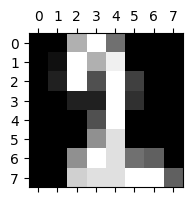

My prediction is 2
sk prediction is 2
Actual number is 2


In [19]:
idx = np.random.randint(X_test.shape[0])
dimage = X_test_org[idx].reshape((8, 8))
plt.figure(figsize=(2, 2))
plt.gray()
plt.matshow(dimage, fignum=0)
plt.show()

X_input = np.expand_dims(X_test[idx], 0)

y_pred = my_predict(layers, X_input)

s_pred = mlp.predict(X_input)

print('My prediction is ' + str(y_pred[0]))
print('sk prediction is ' + str(s_pred[0]))
print('Actual number is ' + str(y_test[idx]))

(c) 2026 S. W. Lee